In [104]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [105]:
df = pd.read_csv('book5.csv')
print(df)

                               Source                        Target  \
0                   Aegon-I-Targaryen            Daenerys-Targaryen   
1    Aegon-Targaryen-(son-of-Rhaegar)            Daenerys-Targaryen   
2    Aegon-Targaryen-(son-of-Rhaegar)                  Elia-Martell   
3    Aegon-Targaryen-(son-of-Rhaegar)              Franklyn-Flowers   
4    Aegon-Targaryen-(son-of-Rhaegar)                        Haldon   
..                                ...                           ...   
755                  Tyrion-Lannister                        Ysilla   
756                   Tywin-Lannister                Wylis-Manderly   
757                 Victarion-Greyjoy                         Wulfe   
758       Walder-Frey-(son-of-Jammos)  Walder-Frey-(son-of-Merrett)   
759                            Yandry                        Ysilla   

           Type  weight  book  
0    undirected       4     5  
1    undirected      11     5  
2    undirected       4     5  
3    undirected    

In [106]:
df = df.dropna(subset=['Source', 'Target', 'weight'])
unique_relationships = len(df.drop_duplicates(subset=['Source', 'Target']))
print(unique_relationships)

760


In [107]:
relationship_counts = df.groupby(['Source', 'Target']).size()
print(relationship_counts)

Source                            Target                      
Aegon-I-Targaryen                 Daenerys-Targaryen              1
Aegon-Targaryen-(son-of-Rhaegar)  Daenerys-Targaryen              1
                                  Elia-Martell                    1
                                  Franklyn-Flowers                1
                                  Haldon                          1
                                                                 ..
Tyrion-Lannister                  Ysilla                          1
Tywin-Lannister                   Wylis-Manderly                  1
Victarion-Greyjoy                 Wulfe                           1
Walder-Frey-(son-of-Jammos)       Walder-Frey-(son-of-Merrett)    1
Yandry                            Ysilla                          1
Length: 760, dtype: int64


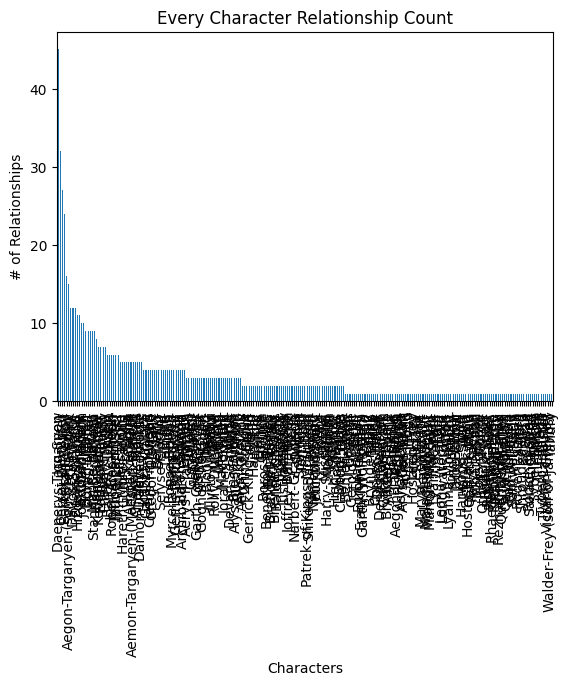

In [108]:
df['Source'].value_counts().plot(kind='bar')
plt.title('Every Character Relationship Count')
plt.xlabel('Characters')
plt.ylabel('# of Relationships')
plt.show()

In [109]:
values = df['Target'].value_counts()
print(values)

Target
Stannis-Baratheon              38
Jon-Snow                       30
Tyrion-Lannister               27
Theon-Greyjoy                  26
Quentyn-Martell                15
                               ..
Walder-Frey-(son-of-Jammos)     1
Wex-Pyke                        1
Willow-Witch-eye                1
Wylis-Manderly                  1
Wulfe                           1
Name: count, Length: 233, dtype: int64


In [110]:
mask = ~df['Target'].isin(df['Source'])
values_not_in_B = df[mask]['Target']
print(values_not_in_B)

9      Rhaenys-Targaryen-(daughter-of-Rhaegar)
13                           Viserys-Targaryen
15                                      Ysilla
23                              Wyman-Manderly
34                                     Rakharo
                        ...                   
755                                     Ysilla
756                             Wylis-Manderly
757                                      Wulfe
758               Walder-Frey-(son-of-Merrett)
759                                     Ysilla
Name: Target, Length: 225, dtype: object


In [111]:
selected_columns = ['Source', 'Target']
all_unique_values = pd.Series(df[selected_columns].values.ravel()).unique()
num = len(all_unique_values)

print(num)

317


In [112]:
melted_df = df[selected_columns].melt(var_name='column', value_name='value')
print("\nMelted DataFrame (first 5 rows):")
print(melted_df.head())

all_counts = melted_df['value'].value_counts()
print("\nValue counts across all specified columns:")
print(all_counts)


Melted DataFrame (first 5 rows):
   column                             value
0  Source                 Aegon-I-Targaryen
1  Source  Aegon-Targaryen-(son-of-Rhaegar)
2  Source  Aegon-Targaryen-(son-of-Rhaegar)
3  Source  Aegon-Targaryen-(son-of-Rhaegar)
4  Source  Aegon-Targaryen-(son-of-Rhaegar)

Value counts across all specified columns:
value
Jon-Snow              62
Daenerys-Targaryen    58
Stannis-Baratheon     47
Theon-Greyjoy         33
Tyrion-Lannister      33
                      ..
William-Foxglove       1
Wex-Pyke               1
Willow-Witch-eye       1
Wylis-Manderly         1
Wulfe                  1
Name: count, Length: 317, dtype: int64


In [113]:
top_10 = all_counts.head(10)
print(top_10)

value
Jon-Snow              62
Daenerys-Targaryen    58
Stannis-Baratheon     47
Theon-Greyjoy         33
Tyrion-Lannister      33
Cersei-Lannister      28
Barristan-Selmy       25
Hizdahr-zo-Loraq      22
Asha-Greyjoy          18
Melisandre            17
Name: count, dtype: int64


In [114]:
three_or_less = all_counts.loc[all_counts <= 3]
print(three_or_less)

value
Pycelle             3
Yellow-Dick         3
Devan-Seaworth      3
Brus-Buckler        3
Sansa-Stark         3
                   ..
William-Foxglove    1
Wex-Pyke            1
Willow-Witch-eye    1
Wylis-Manderly      1
Wulfe               1
Name: count, Length: 189, dtype: int64


In [115]:
bottom_25 = all_counts.tail(25)
print(bottom_25)

value
Lucifer-Long            1
Torghen-Flint           1
Widower                 1
Torgon-Greyiron         1
Larraq                  1
Catelyn-Stark           1
Bartimus                1
Barsena                 1
Lysono-Maar             1
Godric-Borrell          1
Hugh-Hungerford         1
Black-Balaq             1
Yurkhaz-zo-Yunzak       1
Benjen-Stark            1
Quaithe                 1
Pono                    1
Raymun-Redbeard         1
Jon-Umber-(Greatjon)    1
Marghaz-zo-Loraq        1
Aegon-I-Targaryen       1
William-Foxglove        1
Wex-Pyke                1
Willow-Witch-eye        1
Wylis-Manderly          1
Wulfe                   1
Name: count, dtype: int64


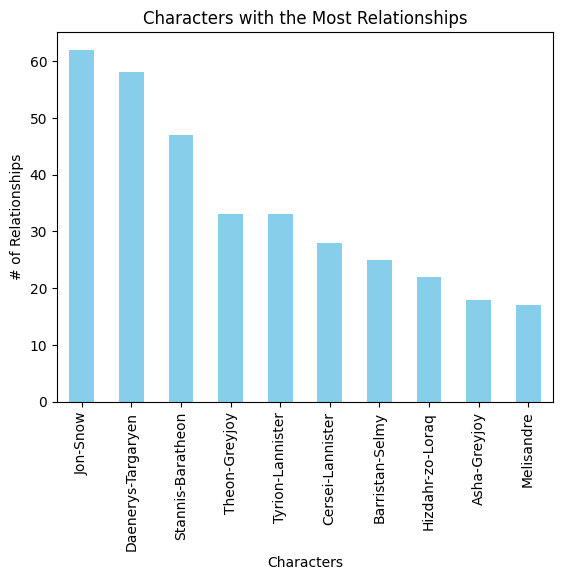

In [116]:
top_10.plot(kind='bar', color='skyblue')

plt.xlabel('Characters')
plt.ylabel('# of Relationships')
plt.title('Characters with the Most Relationships')

plt.show()

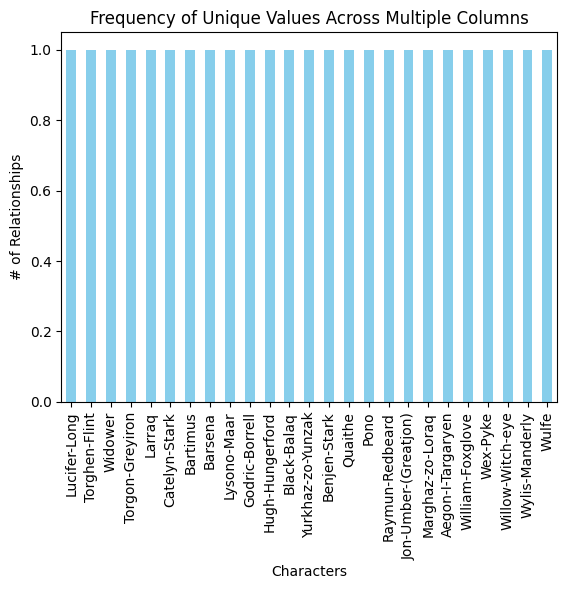

In [117]:
bottom_25.plot(kind='bar', color='skyblue', width=0.5)

plt.xlabel('Characters')
plt.ylabel('# of Relationships')
plt.title('Frequency of Unique Values Across Multiple Columns')

plt.show()

In [118]:
G = nx.from_pandas_edgelist(df, "Source", "Target", edge_attr = ['weight'], create_using=nx.Graph())
pos = nx.spring_layout(G, k=0.9, iterations=50)
print(G)

Graph with 317 nodes and 760 edges


In [119]:
degree_centrality = nx.degree_centrality(G)
node_sizes = [v * 15000 for v in degree_centrality.values()]

In [120]:
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
scaled_weights = [w * 0.5 for w in weights]

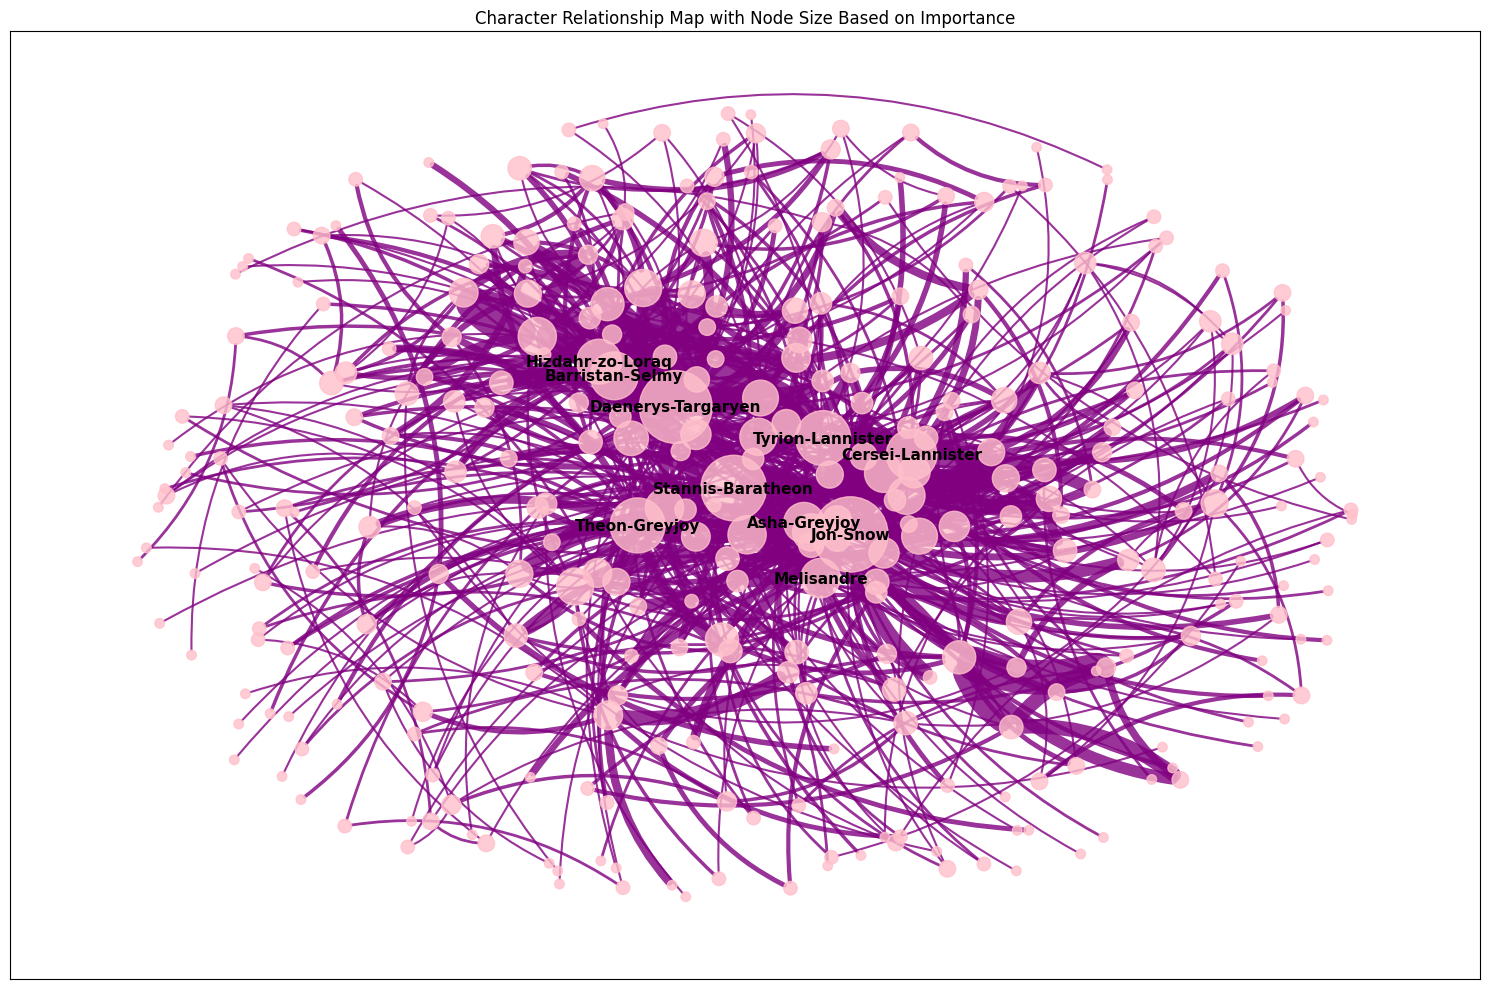

In [121]:
plt.figure(figsize=(15, 10)) # Adjust figure size as needed
nx.draw_networkx(G, pos,
        with_labels=False,
        node_size=node_sizes,
        node_color='pink',
        width=scaled_weights,
        edge_color='purple',
        connectionstyle='arc3,rad=0.2',
        alpha=0.8,
        arrows=True,
        font_size=12)

nx.draw_networkx_labels(G, pos,
    labels={name: name for name in top_10.index},
    font_size=11,
    font_weight="bold",
    font_color="black")

plt.title("Character Relationship Map with Node Size Based on Importance")
plt.tight_layout()
plt.show()

In [122]:
low_relationship_characters = three_or_less.index.tolist()

filtered_edges_df = df[df['Source'].isin(low_relationship_characters) & df['Target'].isin(low_relationship_characters)]

print(filtered_edges_df.head())

            Source            Target        Type  weight  book
21      Aenys-Frey      Hosteen-Frey  undirected       6     5
62           Arron            Emrick  undirected       6     5
77   Arys-Oakheart      Gerold-Dayne  undirected       3     5
94    Ashara-Dayne      Elia-Martell  undirected       3     5
163    Black-Balaq  Franklyn-Flowers  undirected       3     5


In [123]:
G_filtered = nx.from_pandas_edgelist(filtered_edges_df, source='Source', target='Target', edge_attr='weight')
print(G_filtered)

Graph with 57 nodes and 32 edges


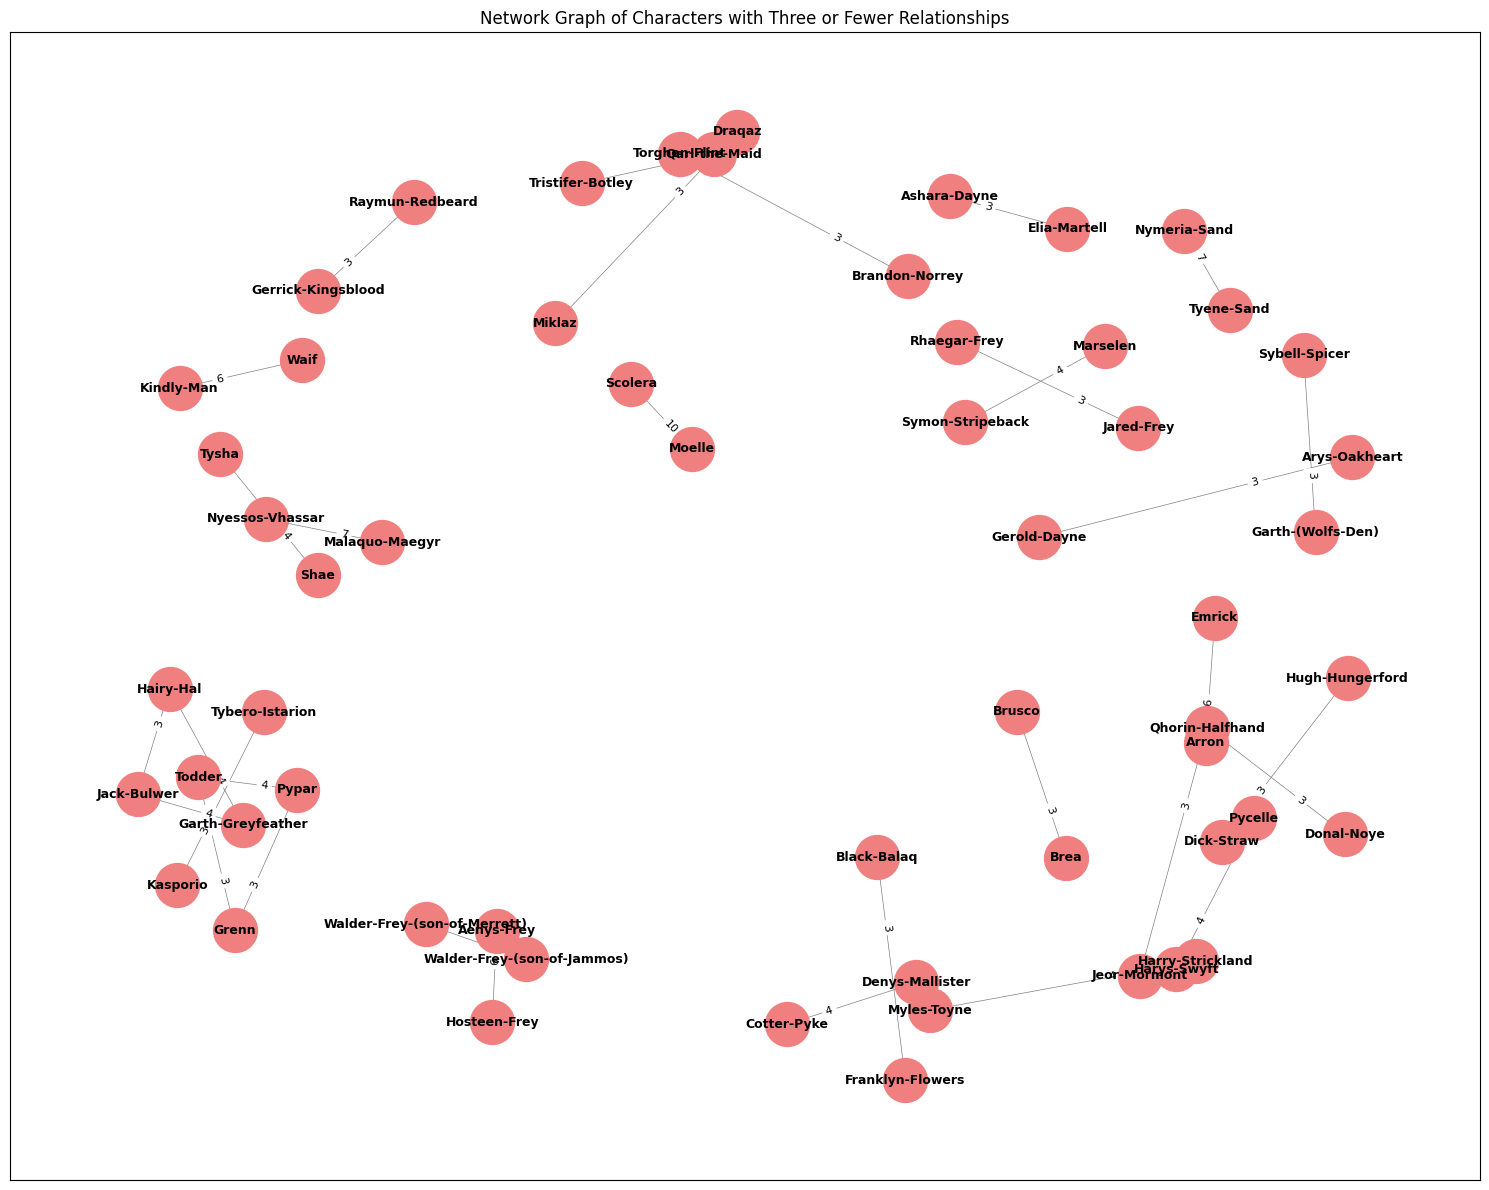

In [124]:
plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G_filtered, k=0.8, iterations=50, scale=5)
nx.draw_networkx(G_filtered, pos,
        with_labels=True,
        node_color='lightcoral',
        node_size=1000,
        edge_color='gray',
        width=0.5,
        font_size=9,
        font_weight='bold')

edge_labels = nx.get_edge_attributes(G_filtered, 'weight')
nx.draw_networkx_edge_labels(G_filtered, pos, edge_labels=edge_labels, font_size=8, label_pos=0.3)

plt.title("Network Graph of Characters with Three or Fewer Relationships")
plt.tight_layout()
plt.show()